In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

In [2]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

prices = data["Close"].dropna()

[*********************100%***********************]  1 of 1 completed


In [3]:
log_returns = np.log(prices / prices.shift(1)).dropna()

In [4]:
mu = log_returns.mean()
sigma = log_returns.std()

print("Mean:", mu)
print("Volatility:", sigma)

Mean: Ticker
AAPL    0.000963
dtype: float64
Volatility: Ticker
AAPL    0.021137
dtype: float64


In [6]:
n_simulations = 10000
n_days = 252
S0 = prices.iloc[-1].item()

returns = np.random.normal(mu, sigma, (n_days, n_simulations))
simulations = S0 * np.exp(np.cumsum(returns, axis=0))

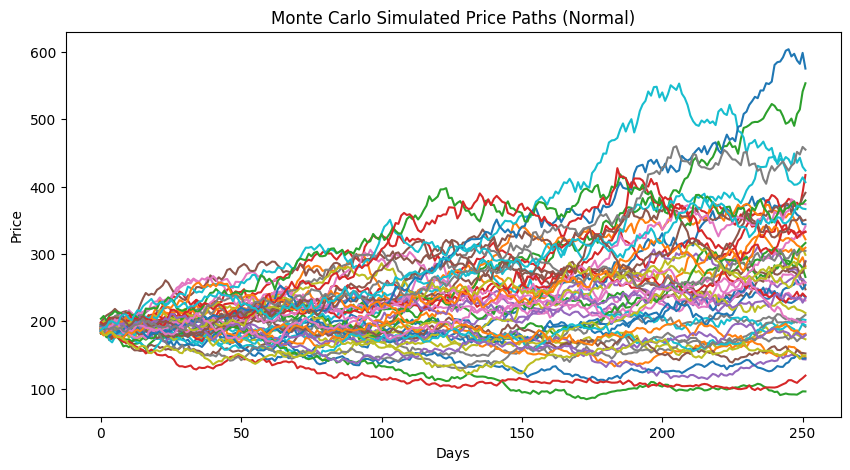

In [7]:
plt.figure(figsize=(10,5))
plt.plot(simulations[:, :50])
plt.title("Monte Carlo Simulated Price Paths (Normal)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [8]:
normal_final = simulations[-1, :] / S0 - 1

In [9]:
def var_es(returns, alpha=0.05):
    var = np.percentile(returns, alpha * 100)
    es = returns[returns <= var].mean()
    return var, es

var_n, es_n = var_es(normal_final)

print("Normal VaR:", var_n)
print("Normal ES:", es_n)

Normal VaR: -0.2650469990444264
Normal ES: -0.3574663068105123


In [10]:
df, loc, scale = stats.t.fit(log_returns)

print("df:", df, "loc:", loc, "scale:", scale)

df: 3.7491828792211797 loc: 0.0012592351757161806 scale: 0.014743345143096314


In [11]:
t_returns = stats.t.rvs(df, loc=loc, scale=scale, size=(n_days, n_simulations))
t_simulations = S0 * np.exp(np.cumsum(t_returns, axis=0))

In [12]:
t_final = t_simulations[-1, :] / S0 - 1

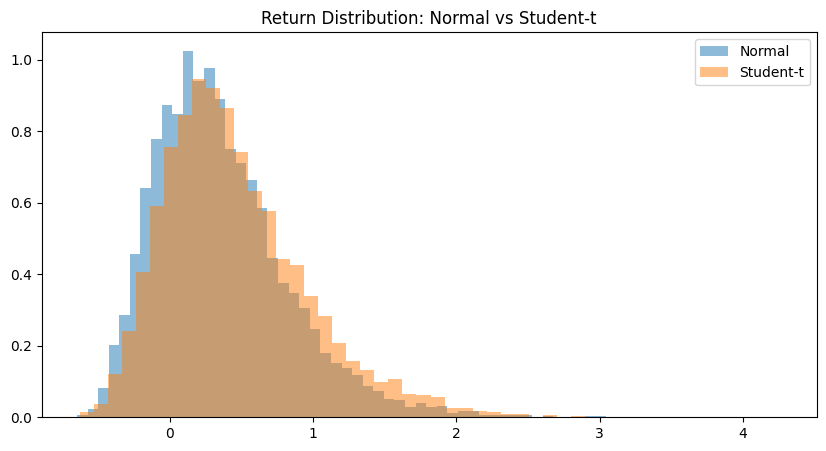

In [13]:
plt.figure(figsize=(10,5))
plt.hist(normal_final, bins=50, alpha=0.5, label="Normal", density=True)
plt.hist(t_final, bins=50, alpha=0.5, label="Student-t", density=True)

plt.title("Return Distribution: Normal vs Student-t")
plt.legend()
plt.show()

In [14]:
var_t, es_t = var_es(t_final)

print("\n--- Comparison ---")
print("Normal VaR:", var_n, "| ES:", es_n)
print("Student-t VaR:", var_t, "| ES:", es_t)


--- Comparison ---
Normal VaR: -0.2650469990444264 | ES: -0.3574663068105123
Student-t VaR: -0.2134792123739672 | ES: -0.31844151263740356


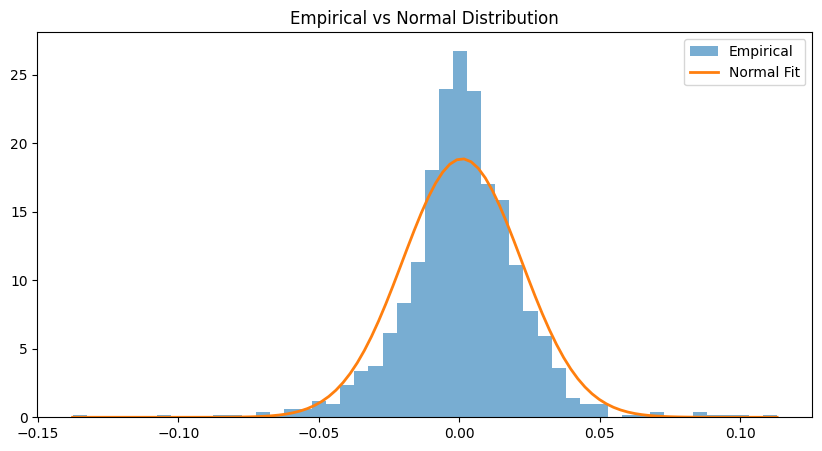

In [15]:
x = np.linspace(log_returns.min(), log_returns.max(), 100)

plt.figure(figsize=(10,5))
plt.hist(log_returns, bins=50, density=True, alpha=0.6, label="Empirical")
plt.plot(x, stats.norm.pdf(x, mu, sigma), label="Normal Fit", linewidth=2)

plt.title("Empirical vs Normal Distribution")
plt.legend()
plt.show()

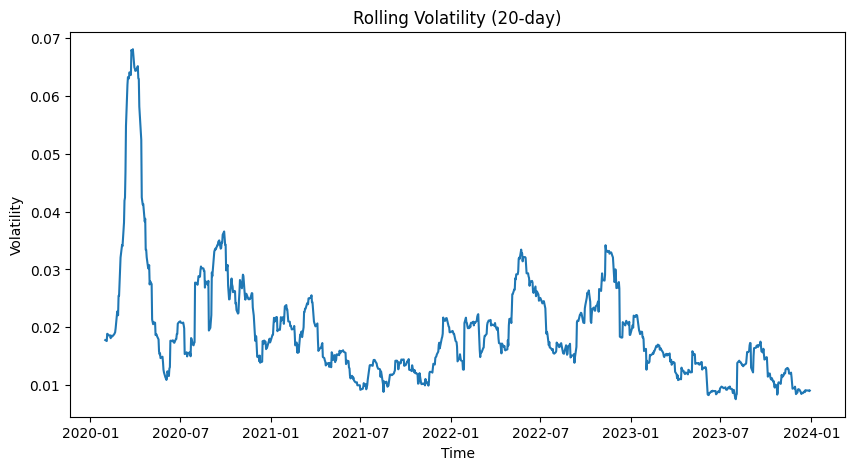

In [16]:
rolling_vol = log_returns.rolling(20).std()

plt.figure(figsize=(10,5))
plt.plot(rolling_vol)
plt.title("Rolling Volatility (20-day)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

## Key Insights

- Financial returns exhibit fat tails, making the normal distribution a poor approximation for extreme events.
- Student-t simulations produce larger tail risk estimates (higher VaR and Expected Shortfall).
- Volatility is time-varying, violating the constant volatility assumption in standard Monte Carlo models.

This highlights the importance of model selection in risk estimation.